In [39]:
"""Imports"""
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [40]:
"""Constants"""
TANK_RADIUS_1T_mm = 525.78
BOTTOM_PADDLE_1_CENTER = (-175, 325, -1228.05)
BOTTOM_PADDLE_2_CENTER = (-43.18, 185.42, -1228.05)
BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
TOP_PADDLE_CENTER = (86,86,766.5)

# for reco simulation
TANK_TOP_Z_mm = 666.75
TANK_BOTTOM_Z_mm = -666.75

In [41]:
"""Functions"""
def load_data(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    return data['reco_events'], data['all_bottom_paddle_tags_for_phase']

def find_intersection_with_z(reco_entry_xy, reco_exit_xy, z_entry, z_exit, target_z):
    """
    Extends a vector defined by two points (reco entry and exit) and finds its intersection
    with a given z-plane.

    Parameters:
        reco_entry_xy (tuple): (x, y) coordinates of the reconstructed entry point
        reco_exit_xy (tuple): (x, y) coordinates of the reconstructed exit point
        z_entry (float): z-coordinate of reco entry point (usually TANK_TOP_Z_mm)
        z_exit (float): z-coordinate of reco exit point (usually TANK_BOTTOM_Z_mm)
        target_z (float): the z-plane you want to intersect with (e.g. 766.5 or -1228.05)

    Returns:
        (x, y, target_z): the 3D point where the line intersects the target_z plane
    """
    p0 = np.array([reco_entry_xy[0], reco_entry_xy[1], z_entry], dtype=float)
    p1 = np.array([reco_exit_xy[0], reco_exit_xy[1], z_exit], dtype=float)
    direction = p1 - p0

    if direction[2] == 0:
        raise ValueError("Vector is parallel to the z-plane; no intersection.")

    t = (target_z - p0[2]) / direction[2]
    intersection = p0 + t * direction
    return tuple(intersection)

def extract_reco_event_data(recos, event_no):
    if BP_tags[event_no] == 1:
        BP_loc = BOTTOM_PADDLE_1_CENTER
    elif BP_tags[event_no] == 2:
        BP_loc = BOTTOM_PADDLE_2_CENTER
    elif BP_tags[event_no] == 3:
        BP_loc = BOTTOM_PADDLE_MIDPOINT
#             continue
#             print("midpoint!")
#         if not throughgoing(recos[i]):
#             continue
    entry_reco_x = recos[event_no]["reco"][0]
    entry_reco_y = recos[event_no]["reco"][1]
    entry_true_x = TOP_PADDLE_CENTER[0]
    entry_true_y = TOP_PADDLE_CENTER[1]

    exit_reco_x = recos[event_no]["reco"][2]
    exit_reco_y = recos[event_no]["reco"][3]
    exit_true_x = BP_loc[0]
    exit_true_y = BP_loc[1]

    top_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, TOP_PADDLE_CENTER[2])
    bot_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, BP_loc[2])

    reco_entry = list(top_intsec)
    reco_exit = list(bot_intsec)
    num_hits = len(recos[event_no]["hits"])
    pmt_positions = np.array([recos[event_no]["hits"][i][:3] for i in range(num_hits)])
    pmt_hit_times_measured = np.array([recos[event_no]["hits"][i][3] for i in range(num_hits)])

    return reco_entry, reco_exit, pmt_positions, pmt_hit_times_measured

def compute_expected_pmt_times(
    reco_entry, reco_exit, t0_true,
    pmt_positions, pmt_hit_times_measured,
    n=1.33, c=299_792_458
):
    """
    Computes expected hit times at PMTs using reconstructed muon track.
    
    Parameters:
        reco_entry: [x, y, z] of reconstructed entry point
        reco_exit: [x, y, z] of reconstructed exit point
        t0_true: float, true entry time of muon (in seconds)
        pmt_positions: list of 58 [x, y, z] PMT positions (in mm)
        pmt_hit_times_measured: list of 58 observed PMT hit times (in seconds)
        n: refractive index of water (default 1.33)
        c: speed of light in vacuum (in m/s)

    Returns:
        expected_hit_times: list of 58 expected PMT hit times (in seconds)
    """
    pmt_positions = np.array(pmt_positions)  # shape (58, 3)
    reco_entry = np.array(reco_entry)
    reco_exit = np.array(reco_exit)

    # Convert mm to meters for all positions
    reco_entry /= 1000
    reco_exit /= 1000
    pmt_positions /= 1000

    # Track direction unit vector
    track_dir = reco_exit - reco_entry
    track_length = np.linalg.norm(track_dir)
    track_dir /= track_length

    # Cherenkov angle
    theta_c = np.arccos(1 / n)

    expected_hit_times = []

    for pmt_pos in pmt_positions:
        # Scan along the track to find best emission point
        best_time = None
        min_angle_diff = float('inf')

        # Sample points along the track
        for alpha in np.linspace(0, track_length, 100):
            emit_pos = reco_entry + alpha * track_dir
            vec_to_pmt = pmt_pos - emit_pos
            vec_to_pmt_unit = vec_to_pmt / np.linalg.norm(vec_to_pmt)

            # Compute angle between emission-to-PMT and track direction
            cos_theta = np.dot(vec_to_pmt_unit, track_dir)
            angle = np.arccos(np.clip(cos_theta, -1, 1))

            angle_diff = abs(angle - theta_c)

            if angle_diff < min_angle_diff:
                min_angle_diff = angle_diff

                # Time = muon travel to emit point + photon travel to PMT
                t_muon = alpha / c
                t_photon = np.linalg.norm(vec_to_pmt) / (c / n)
                best_time = t0_true + t_muon + t_photon

        expected_hit_times.append(best_time)

    return expected_hit_times


In [44]:
user_file_choice = 2

### eloss files
elosstank_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_all/07_09_25_reco_elosstank_digit_weight_all_disk_e_phase_3_1.pkl"
elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_all/07_09_25_reco_elosstank_digit_edge_all_disk_e_phase_3_1.pkl"
elosstank_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_per/07_09_25_reco_elosstank_digit_weight_per_disk_e_phase_3_1.pkl"
elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_per/07_09_25_reco_elosstank_digit_edge_per_disk_e_phase_3_1.pkl"

### numCher files
numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_all/07_09_25_reco_numCher_digit_edge_all_disk_e_phase_3_1.pkl"
numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_per/07_09_25_reco_numCher_digit_edge_per_disk_e_phase_3_1.pkl"
numCher_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_all/07_09_25_reco_numCher_digit_weight_all_disk_e_phase_3_1.pkl"
numCher_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_per/07_09_25_reco_numCher_digit_weight_per_disk_e_phase_3_1.pkl"

file_list = [
    elosstank_digit_weight_all,  #0
    elosstank_digit_edge_all,    #1
    elosstank_digit_weight_per,  #2
    elosstank_digit_edge_per,    #3
    numCher_digit_edge_all,      #4
    numCher_digit_edge_per,      #5
    numCher_digit_weight_all,    #6
    numCher_digit_weight_per     #7
]
real_file = file_list[user_file_choice]
reco_events, BP_tags = load_data(real_file)

reco_entry, reco_exit, pmt_positions, pmt_hit_times_measured = extract_reco_event_data(recos=reco_events, event_no=10)
print(pmt_hit_times_measured)
# reco_type = real_file.split("/")[10]
# hist_tag = str(reco_type)

[63.13574698 63.8487042  62.46887928 63.074513   62.25474416 61.50563603
 62.86982213 60.41074539 62.95371631 62.15576809 60.84189618 63.19703268
 62.80002139 62.64619858 62.58142173 60.56845483 63.02680487 61.84260469
 64.05884417 63.39387059 60.17851273 63.57771832 60.         62.50500904
 63.30359661 61.58870422 63.86957726 62.45559744 64.49896566 62.29452832
 60.9888857  62.66021566 60.21219858 63.2289202  63.47107158 63.19052892
 63.25138938 62.56567034 63.30912874]


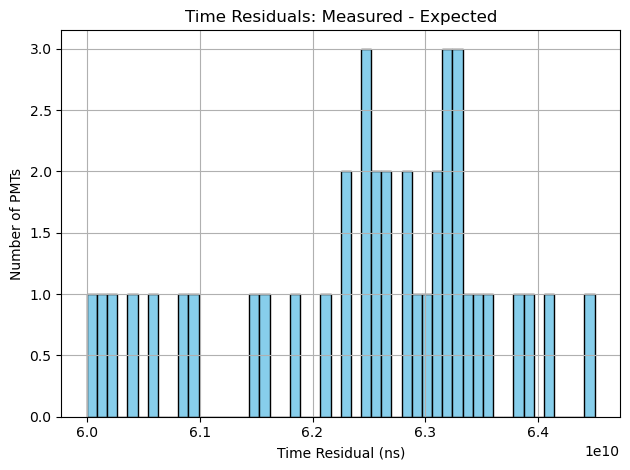

In [54]:
expected_times = compute_expected_pmt_times(
    reco_entry,
    reco_exit,
    60e-9,  # true_t0, in seconds
    pmt_positions,  # shape (58, 3)
    pmt_hit_times_measured)


residuals = np.array(pmt_hit_times_measured) - np.array(expected_times)

plt.hist(residuals * 1e9, bins=50, color='skyblue', edgecolor='k')
plt.xlabel('Time Residual (ns)')
plt.ylabel('Number of PMTs')
plt.title('Time Residuals: Measured - Expected')
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
def compute_expected_pmt_times_conical(
    reco_entry, reco_exit, t0_true,
    pmt_positions, n=1.33, c=299_792_458
):
    """
    Computes expected hit times using Cherenkov cone geometry.

    Parameters:
        reco_entry: [x, y, z] in mm
        reco_exit: [x, y, z] in mm
        t0_true: true entry time (s)
        pmt_positions: list of 58 [x, y, z] in mm
        n: refractive index
        c: speed of light in vacuum (m/s)

    Returns:
        List of expected hit times (np.nan if unreachable)
    """
    reco_entry = np.array(reco_entry) / 1000  # mm → m
    reco_exit = np.array(reco_exit) / 1000
    pmt_positions = np.array(pmt_positions) / 1000  # shape (58, 3)

    track_dir = reco_exit - reco_entry
    track_len = np.linalg.norm(track_dir)
    track_dir /= track_len  # normalize

    theta_c = np.arccos(1 / n)  # Cherenkov angle in radians
    expected_hit_times = []

    for pmt in pmt_positions:
        found = False
        best_time = np.nan
        best_angle_error = np.inf

        # Sample points along the track (step ~1 cm)
        for alpha in np.linspace(0, track_len, int(track_len * 100)):
            emit_pos = reco_entry + alpha * track_dir
            vec_to_pmt = pmt - emit_pos
            dist_to_pmt = np.linalg.norm(vec_to_pmt)

            if dist_to_pmt == 0:
                continue

            photon_dir = vec_to_pmt / dist_to_pmt
            cos_angle = np.dot(photon_dir, track_dir)
            angle = np.arccos(np.clip(cos_angle, -1, 1))

            # Accept only if close to Cherenkov angle
            if abs(angle - theta_c) < np.deg2rad(1.0):  # within 1 degree
                t_muon = alpha / c
                t_photon = dist_to_pmt / (c / n)
                best_time = t0_true + t_muon + t_photon
                found = True
                break  # stop at first good match

        expected_hit_times.append(best_time)

    return expected_hit_times


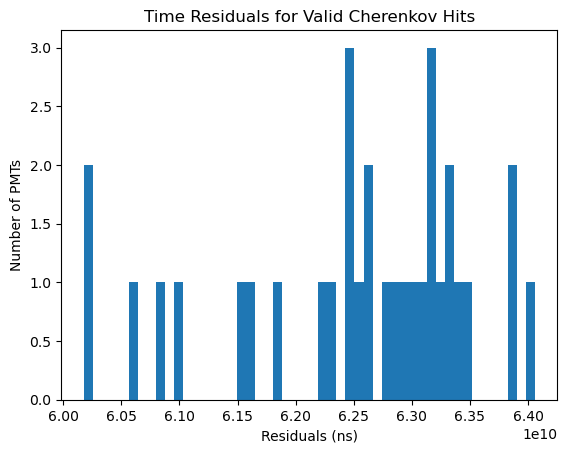

In [58]:
expected = np.array(compute_expected_pmt_times_conical(
    reco_entry,
    reco_exit,
    60e-9,  # true_t0, in seconds
    pmt_positions,  # shape (58, 3)
)
                   )
measured = np.array(pmt_hit_times_measured)

valid_mask = ~np.isnan(expected)
residuals = measured[valid_mask] - expected[valid_mask]

plt.hist(residuals * 1e9, bins=50)
plt.xlabel("Residuals (ns)")
plt.ylabel("Number of PMTs")
plt.title("Time Residuals for Valid Cherenkov Hits")
plt.show()
